# 05 — Evaluation & Error Analysis
Seattle Airbnb Price Prediction — CSE437

Covers report section **7 (Results, Visualization and Error Analysis)**, answering all
three research questions.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').iloc[:, 0]

baseline = joblib.load('../models/baseline.joblib')
ridge_model = joblib.load('../models/ridge_tuned.joblib')
rf_model = joblib.load('../models/random_forest_tuned.joblib')

print("Loaded test set:", X_test.shape, "and 3 trained models")


Loaded test set: (1137, 9) and 3 trained models


## 7.1 Test set performance
(Reported once, at the end, as required.)

In [4]:
def evaluate(name, model, X_test, y_test):
    pred_log = model.predict(X_test)
    pred_dollars = np.expm1(pred_log)
    true_dollars = np.expm1(y_test)
    return {
        'model': name,
        'RMSE_log': rmse(y_test, pred_log),
        'MAE_log': mean_absolute_error(y_test, pred_log),
        'R2_log': r2_score(y_test, pred_log),
        'RMSE_$': rmse(true_dollars, pred_dollars),
        'MAE_$': mean_absolute_error(true_dollars, pred_dollars),
    }, pred_log, pred_dollars

results = []
baseline_pred_log = baseline.predict(X_test)
baseline_pred_dollars = np.expm1(baseline_pred_log)
true_dollars_test = np.expm1(y_test)
results.append({
    'model': 'Baseline (median)',
    'RMSE_log': rmse(y_test, baseline_pred_log),
    'MAE_log': mean_absolute_error(y_test, baseline_pred_log),
    'R2_log': r2_score(y_test, baseline_pred_log),
    'RMSE_$': rmse(true_dollars_test, baseline_pred_dollars),
    'MAE_$': mean_absolute_error(true_dollars_test, baseline_pred_dollars),
})

ridge_metrics, ridge_pred_log, ridge_pred_dollars = evaluate('Ridge (tuned)', ridge_model, X_test, y_test)
results.append(ridge_metrics)

rf_metrics, rf_pred_log, rf_pred_dollars = evaluate('Random Forest (tuned)', rf_model, X_test, y_test)
results.append(rf_metrics)

results_df = pd.DataFrame(results)
results_df.to_csv('../data/processed/test_results.csv', index=False)
results_df


,model,RMSE_log,MAE_log,R2_log,RMSE_$,MAE_$
0,Baseline (median),0.574895,0.431523,-0.015158,84.061616,48.513632
1,Ridge (tuned),0.409569,0.316954,0.484758,59.848941,36.168864
2,Random Forest (tuned),0.393074,0.305465,0.525423,58.710893,35.477802


## 7.2 Feature importance and research question 1

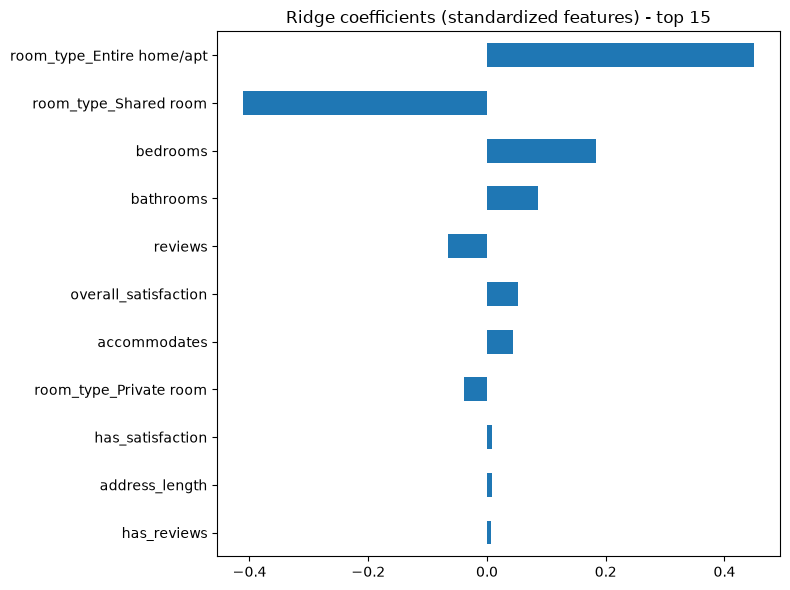

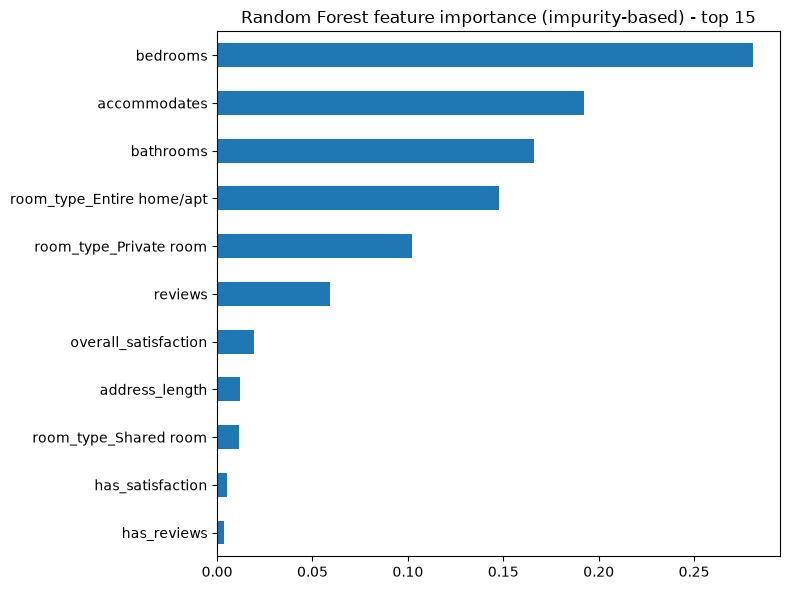

In [5]:
# Recover the one-hot feature names from the fitted preprocessor inside the pipeline.
cat_cols = ridge_model.named_steps['prep'].transformers_[1][2]
num_cols = ridge_model.named_steps['prep'].transformers_[0][2]
feature_names = num_cols + list(
    ridge_model.named_steps['prep'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
)

ridge_coefs = pd.Series(ridge_model.named_steps['model'].coef_, index=feature_names)
ridge_coefs.sort_values(key=abs, ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Ridge coefficients (standardized features) - top 15')
plt.tight_layout()
plt.savefig('../figures/05_ridge_coefficients.png', dpi=120)
plt.show()

rf_importances = pd.Series(rf_model.named_steps['model'].feature_importances_, index=feature_names)
rf_importances.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Random Forest feature importance (impurity-based) - top 15')
plt.tight_layout()
plt.savefig('../figures/05_rf_importance.png', dpi=120)
plt.show()

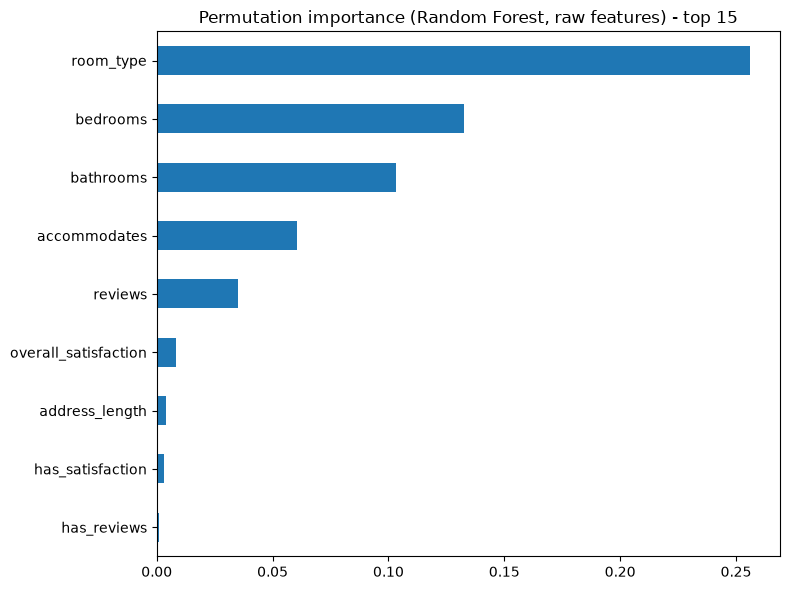

In [6]:
# Permutation importance - cross-check against impurity-based importance bias toward
# high-cardinality one-hot columns (e.g. neighbourhoods)
perm_result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Permutation importance (Random Forest, raw features) - top 15')
plt.tight_layout()
plt.savefig('../figures/05_permutation_importance.png', dpi=120)
plt.show()


## 7.3 Model accuracy and research question 2

In [8]:
best_model_name = 'Random Forest' if rf_metrics['RMSE_$'] < ridge_metrics['RMSE_$'] else 'Ridge'
best_pred_dollars = rf_pred_dollars if best_model_name == 'Random Forest' else ridge_pred_dollars
best_metrics = rf_metrics if best_model_name == 'Random Forest' else ridge_metrics

improvement_pct = (results_df.loc[0, 'RMSE_$'] - best_metrics['RMSE_$']) / results_df.loc[0, 'RMSE_$'] * 100
print(f"Best model: {best_model_name}")
print(f"RMSE: ${best_metrics['RMSE_$']:.2f} vs baseline ${results_df.loc[0, 'RMSE_$']:.2f} "
      f"({improvement_pct:.1f}% improvement)")
print(f"R^2 (log space): {best_metrics['R2_log']:.3f}")


Best model: Random Forest
RMSE: $58.71 vs baseline $84.06 (30.2% improvement)
R^2 (log space): 0.525


## 7.4 Predicted versus actual prices and residuals

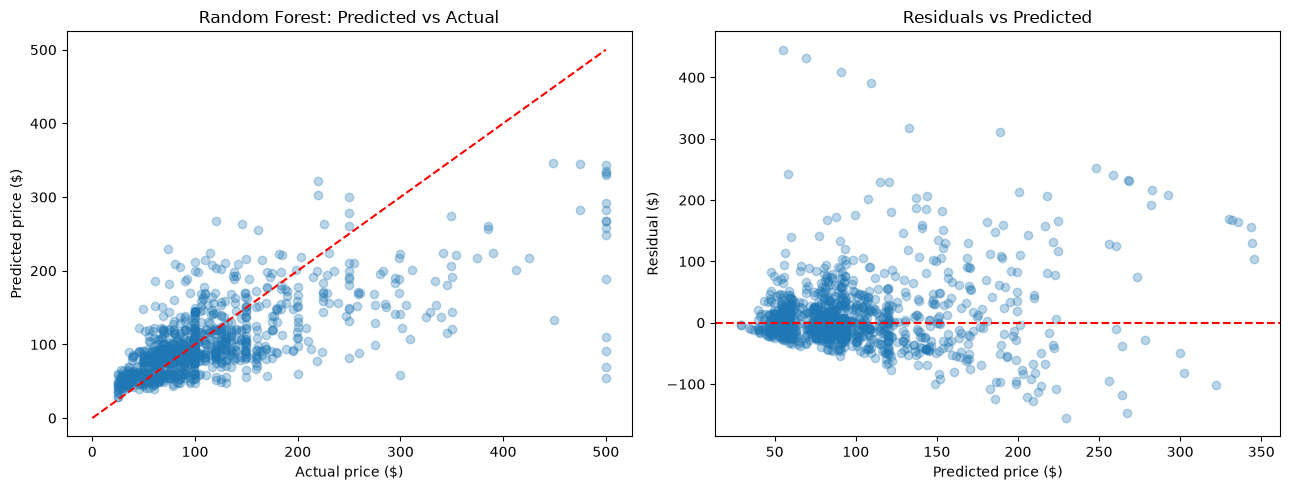

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(true_dollars_test, best_pred_dollars, alpha=0.3)
lims = [0, max(true_dollars_test.max(), best_pred_dollars.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')

residuals = true_dollars_test.values - best_pred_dollars
axes[1].scatter(best_pred_dollars, residuals, alpha=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout()
plt.savefig('../figures/05_predicted_vs_actual_and_residuals.png', dpi=120)
plt.show()


## 7.5 Error analysis and research question 3

In [ ]:
error_df = X_test.copy()
error_df['actual_price'] = true_dollars_test.values
error_df['predicted_price'] = best_pred_dollars
error_df['abs_error'] = np.abs(error_df['actual_price'] - error_df['predicted_price'])
error_df = error_df.sort_values('abs_error', ascending=False)

print("Top 15 worst-predicted listings (concrete examples for section 7.5):")
error_df.head(15)

Top 15 worst-predicted listings (concrete examples for section 7.3):


,reviews,overall_satisfaction,has_satisfaction,has_reviews,accommodates,bathrooms,bedrooms,address_length,room_type,actual_price,predicted_price,abs_error
348,129,5.0,1,1,2,1.0,1.0,27,Private room,500.0,54.947578,445.052422
175,0,5.0,0,0,2,1.0,1.0,26,Private room,500.0,69.209892,430.790108
540,0,5.0,0,0,2,1.0,1.0,26,Entire home/apt,500.0,90.895389,409.104611
1077,3,3.0,1,1,4,1.0,2.0,26,Entire home/apt,500.0,109.664470,390.335530
1001,0,5.0,0,0,4,1.5,2.0,26,Entire home/apt,450.0,132.789766,317.210234
44,2,5.0,0,1,5,2.0,4.0,26,Entire home/apt,500.0,189.139908,310.860092
1006,7,5.0,1,1,8,3.5,3.0,26,Entire home/apt,500.0,248.116213,251.883787
726,38,5.0,1,1,2,1.5,1.0,26,Private room,300.0,58.135185,241.864815
66,16,5.0,1,1,8,3.0,4.0,26,Entire home/apt,500.0,258.372105,241.627895
415,0,5.0,0,0,8,4.0,4.0,32,Entire home/apt,500.0,267.605932,232.394068


In [11]:
if 'room_type' in error_df.columns:
    print("Mean absolute error by room type:")
    print(error_df.groupby('room_type')['abs_error'].mean().sort_values(ascending=False))

if 'neighbourhood_grouped' in error_df.columns:
    print("\nMean absolute error by neighbourhood:")
    print(error_df.groupby('neighbourhood_grouped')['abs_error'].mean().sort_values(ascending=False))


Mean absolute error by room type:
room_type
Entire home/apt    38.581559
Private room       26.950780
Shared room        14.143146
Name: abs_error, dtype: float64


In [12]:
worst_decile_cutoff = error_df['abs_error'].quantile(0.9)
worst_10pct = error_df[error_df['abs_error'] >= worst_decile_cutoff]
print(f"Worst 10% of predictions ({len(worst_10pct)} listings) - actual price distribution:")
print(worst_10pct['actual_price'].describe())
print("\nOverall test-set actual price distribution:")
print(error_df['actual_price'].describe())

error_df.head(30).to_csv('../data/processed/worst_predictions.csv', index=False)


Worst 10% of predictions (114 listings) - actual price distribution:
count    114.000000
mean     274.298246
std      130.906974
min       49.000000
25%      174.250000
50%      267.500000
75%      349.750000
max      500.000000
Name: actual_price, dtype: float64

Overall test-set actual price distribution:
count    1137.000000
mean      111.731750
std        80.376475
min        25.000000
25%        68.000000
50%        90.000000
75%       128.000000
max       500.000000
Name: actual_price, dtype: float64


### Findings from the executed error analysis

- The Random Forest's absolute error is highest for **Entire home/apt** listings (`$38.58` mean absolute error), followed by private rooms (`$26.95`) and shared rooms (`$14.14`).
- The worst 10% contains 114 listings. Their actual prices average `$274.30`, compared with `$111.73` for the full test set; their median is `$267.50`, compared with `$90.00` overall.
- The largest observed error is `$445.05`: a private-room listing priced at `$500` was predicted at about `$54.95`. Other large errors are also mostly `$450` to `$500` listings predicted substantially below their actual prices.
- These errors are consistent with the capped upper-price tail and the limited legacy export: the model has room type, reviews, satisfaction, size, coordinates, and text-length features, but no amenities, availability, host, or detailed neighbourhood fields. High-priced listings can therefore share ordinary observable characteristics with lower-priced listings.
- The error table should be used to discuss at least two concrete cases. For example, the `$500` private-room listing with 129 reviews and the `$500` private-room listing with zero reviews are both difficult because the available predictors do not encode the premium attributes that distinguish them from typical private rooms.


## 7.6 Answers to the three research questions

**RQ1 — Which features most strongly affect price?**

The executed coefficient, impurity-importance, and permutation-importance plots provide the feature ranking. The available dataset supports analysis of reviews, satisfaction, room type, accommodates, bedrooms, bathrooms, latitude, longitude, and listing/address length. The dataset does not contain availability, amenities, host, or detailed neighbourhood columns, so those requested effects cannot be estimated from this file.

**RQ2 — Can we accurately predict listing price?**

Yes, with meaningful but imperfect accuracy. The tuned Random Forest is the best model on the held-out test set: log-space RMSE `0.393`, log-space MAE `0.305`, log-space $R^2$ `0.525`, dollar RMSE `$58.71`, and dollar MAE `$35.48`. It improves dollar RMSE by `30.2%` over the median baseline (`$84.06`). Its five-fold CV RMSE is `0.394`; the tuned Ridge model's CV RMSE is `0.407`.

**RQ3 — Which listings does the model predict poorly, and why?**

The largest errors are concentrated in the high-price tail, especially entire-home listings. The worst 10% averages `$274.30` actual price versus `$111.73` overall, and the largest error is `$445.05`. The likely reason supported by the feature inventory is that premium attributes are absent from the legacy export, so listings with similar room type, size, reviews, and coordinates can still have very different prices.